### EDA

In [8]:
import sys
print(sys.executable)

c:\Users\ASUS\Desktop\EdgeIA_PFE\venv\Scripts\python.exe


In [9]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

In [7]:
images_path = Path("../data/raw/images")
labels_path = Path("../data/raw/labels")

# ── Plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Images dir exists:', images_path.exists())
print('Labels dir exists:', labels_path.exists())

Images dir exists: True
Labels dir exists: True


##### 1-Dataset overview
Count how many image and label files exist, and check for mismatches between the two.

In [19]:
image_exts = ['*.png','*.jpg','*.jpeg']
image_files = []

for ext in image_exts:
    image_files += list(images_path.rglob(ext))

label_files = list(labels_path.rglob('*.txt')) 

print(image_files[0])
# Build stem sets for mismatch detection
image_stems = {f.stem for f in image_files}
label_stems = {f.stem for f in label_files}

images_without_labels = image_stems - label_stems
labels_without_images = label_stems - image_stems

print(f'Total images : {len(image_files)}')
print(f'Total label files : {len(label_files)}')
print(f'Images missing labels : {len(images_without_labels)}')
print(f'Labels missing images : {len(labels_without_images)}')

if images_without_labels:
    print('\n Sample images without labels:', list(images_without_labels)[:5])
if labels_without_images:
    print('Sample labels without images:', list(labels_without_images)[:5])



..\data\raw\images\GX010023_frame_00000_jpg.rf.Q2WZf7zPwjKpg3m7NQ6o.jpg
Total images : 753
Total label files : 753
Images missing labels : 0
Labels missing images : 0


##### 2- Image Resolution Analysis

Check if all images share the same resolution, or if mixed sizes will require resizing at training time.

Unique resolutions found:
1625x900 - 664 images (88.2%)
885x996 - 74 images (9.8%)
3250x900 - 14 images (1.9%)
915x900 - 1 images (0.1%)


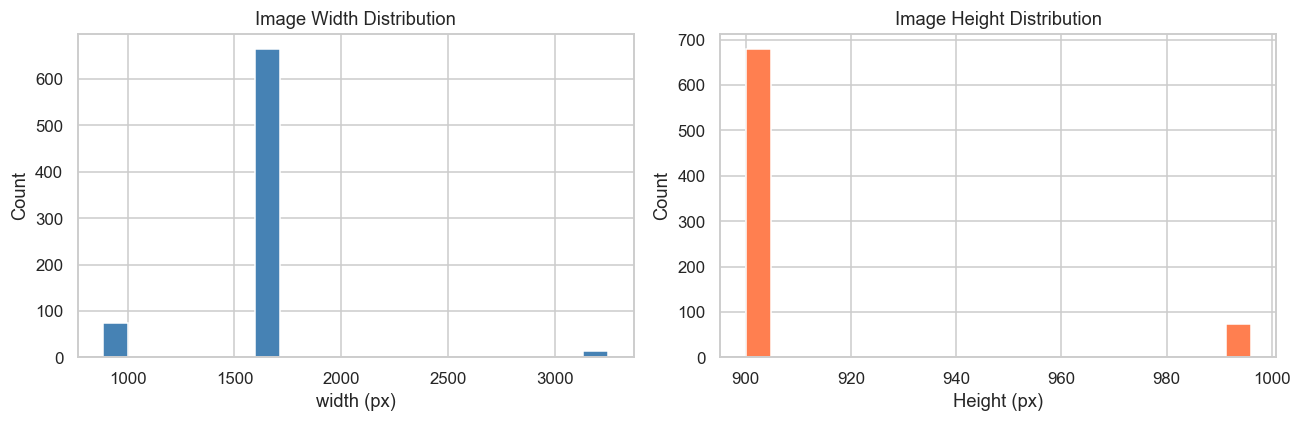

In [73]:
widths, heights = [], []

for img_path in image_files:
    with Image.open(img_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

resolution_counter = Counter(zip(widths, heights))
# print(resolution_counter)
print('Unique resolutions found:')
for res, count in resolution_counter.most_common():
    print(f'{res[0]}x{res[1]} - {count} images ({count/len(image_files)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(widths, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('width (px)')
axes[0].set_ylabel('Count')

axes[1].hist(heights, bins=20, color='coral', edgecolor='white')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/plots/eda_resolution.png', bbox_inches='tight')
plt.show()

##### 3- Annotation analysis

Parse every `.txt` label file (YOLO format: `class x_center y_center width height`, all normalised 0–1).  
We want to know:
- How many annotations per image (crowd density)
- Whether there are unannotated images (blank negatives)
- Which classes appear (should only be class `0` = person)

In [ ]:
annotations_per_image = []
all_classes = []
all_bboxes = []
empty_label_files = []

for lbl_path in label_files:
    lines = lbl_path.read_text().strip().splitlines()
    #filter out blank lines
    valid_lines = [l for l in lines if l.strip()]
    
    if len (valid_lines) == 0:
        empty_label_files.append(lbl_path)
        annotations_per_image.append(0)
        continue
    annotations_per_image.append(len(valid_lines))
    for line in valid_lines:
        parts = line.split()
        cls = int(parts[0])
        xc,  yc, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        all_classes.append(cls)
        all_bboxes.append((xc, yc, bw, bh))

all_bboxes = np.array(all_bboxes)
class_counter = Counter(all_classes)

print(f'Total annotations : {len(all_bboxes)}')
print(f'Avg annotations / image : {np.mean(annotations_per_image)}')
print(f'Max annotations / image : {np.max(annotations_per_image)}')
print(f'Empty label files (no annotations) : {len(empty_label_files)}')
print(f'Class distribution : {dict(class_counter)}')
if len(class_counter) > 1:
    print('Multi classes detected')
else:
    print('single classes (person) confirmed.')

Total annotations : 6273
Avg annotations / image : 8.330677290836654
Max annotations / image : 30
Empty label files (no annotations) : 0
Class distribution : {0: 6273}
single classes (person) confirmed.


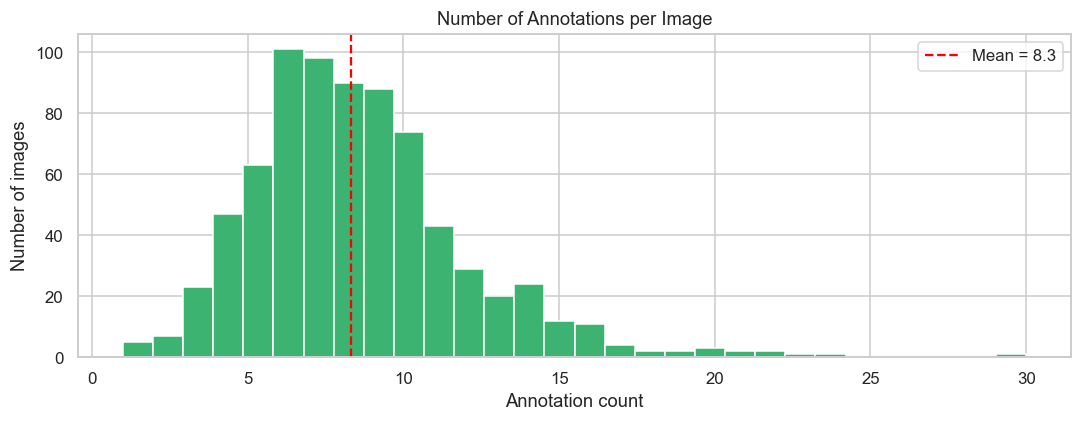

In [74]:
#Distribution of annotation count per image_exts
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(annotations_per_image, bins=30, color='mediumseagreen', edgecolor='white')
ax.set_title("Number of Annotations per Image")
ax.set_xlabel('Annotation count')
ax.set_ylabel('Number of images')
ax.axvline(np.mean(annotations_per_image), color='red', linestyle='--', label=f'Mean = {np.mean(annotations_per_image):.1f}')
ax.legend()
plt.tight_layout()
plt.savefig('../data/plots/eda_annotations_per_images', bbox_inches='tight')
plt.show()

##### 4. Bounding Box size Analysis

This step answers one critical question: are people big or small in your images? This directly affects how well YOLOv5n will detect them. `YOLOv5 uses anchor boxes `

`Why a threshold of 0.03 (3%)`: This threshold to detect the people that are only occupies less than 3% (0.03) of the image, which is very difficult for YOLOv5 to detect from. (YOLOv5 is using a 640px input -- 3% = 19px)

In [63]:
bbox_widths = all_bboxes[:, 2]
bbox_heights = all_bboxes[:, 3]
bbox_areas = bbox_widths * bbox_heights

print('Bounding Box Statistics (normalised 0-1):')
print(f'Width - mean: {bbox_widths.mean():.4f} | median: {np.median(bbox_widths):.4f} | min: {bbox_widths.min():.4f} | max: {bbox_widths.max():.4f}')
print(f'Height - mean: {bbox_heights.mean():.4f} | median: {np.median(bbox_heights):.4f} | min: {bbox_heights.min():.4f} | max: {bbox_heights.max():.4f}')
print(f'Area - mean: {bbox_areas.mean():.6f} | median: {np.median(bbox_areas):.6f}')

tiny_threshold = 0.03  # less than 3% of image dimension = very small object
tiny_boxes = np.sum((bbox_widths < tiny_threshold) | (bbox_heights < tiny_threshold))
print(f'\nTiny boxes (w or h < {tiny_threshold}): {tiny_boxes} ({tiny_boxes/len(all_bboxes)*100:.1f}%)')
if tiny_boxes / len(all_bboxes) > 0.2:
    print('Consider anchor recomputation and input resolution ≥ 640.')

Bounding Box Statistics (normalised 0-1):
Width - mean: 0.0967 | median: 0.0894 | min: 0.0254 | max: 0.3203
Height - mean: 0.4300 | median: 0.4378 | min: 0.0632 | max: 0.6837
Area - mean: 0.041637 | median: 0.039514

Tiny boxes (w or h < 0.03): 6 (0.1%)


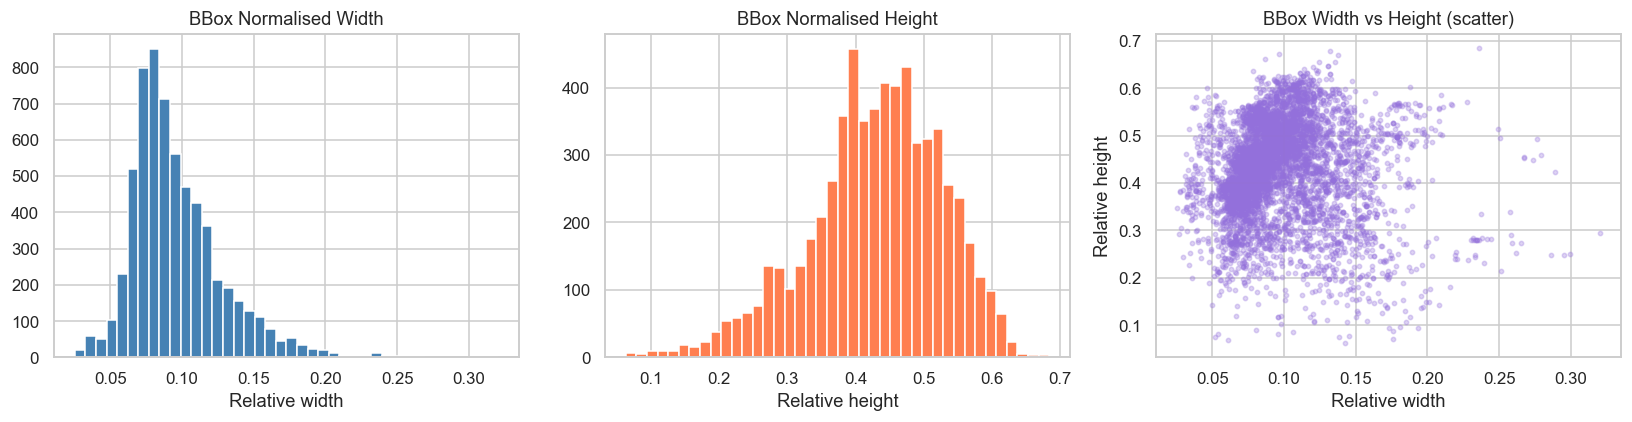

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(bbox_widths, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('BBox Normalised Width')
axes[0].set_xlabel('Relative width')

axes[1].hist(bbox_heights, bins=40, color='coral', edgecolor='white')
axes[1].set_title('BBox Normalised Height')
axes[1].set_xlabel('Relative height')

axes[2].scatter(bbox_widths, bbox_heights, alpha=0.3, s=8, color='mediumpurple')
axes[2].set_title('BBox Width vs Height (scatter)')
axes[2].set_xlabel('Relative width')
axes[2].set_ylabel('Relative height')

plt.tight_layout()
plt.savefig('../data/plots/eda_bbox_sizes.png', bbox_inches='tight')
plt.show()

##### 5. Spatial distribution of bbox centers

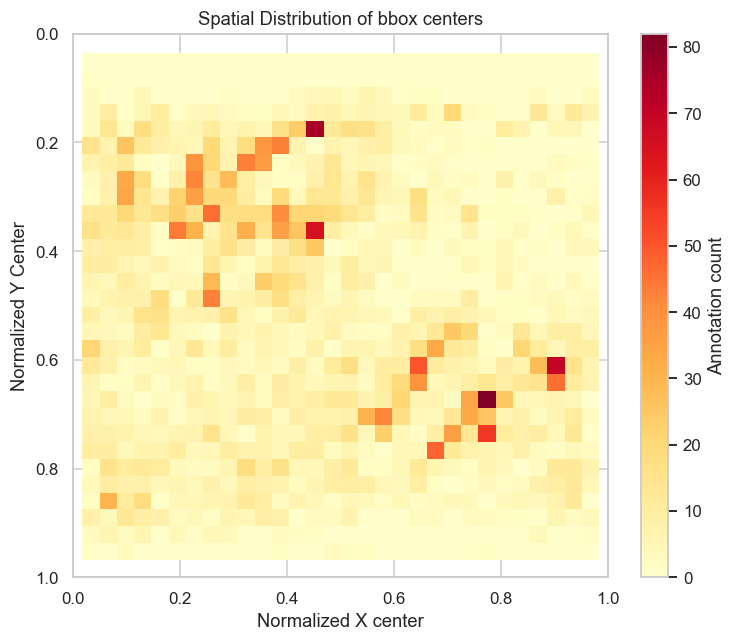

In [76]:
cx = all_bboxes[:, 0]
cy = all_bboxes[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
h = ax.hist2d(cx, cy, bins=30, cmap='YlOrRd')
plt.colorbar(h[3], ax=ax, label='Annotation count')
ax.set_title('Spatial Distribution of bbox centers')
ax.set_xlabel('Normalized X center')
ax.set_ylabel('Normalized Y Center')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../data/plots/eda_spatial_distribution.png')
plt.show()

##### 6. Summary

In [77]:
print(f'Total images : {len(image_files)}')
print(f'Total annotations : {len(all_bboxes)}')
print(f'Avg persons / image : {np.mean(annotations_per_image):.2f}')
print(f'Empty label files : {len(empty_label_files)}')
print(f'Unique classes : {list(class_counter.keys())}')
print(f'Median bbox width : {np.median(bbox_widths):.4f}')
print(f'Median bbox height : {np.median(bbox_heights):.4f}')
print(f'Tiny boxes (< 3% dim) : {tiny_boxes} ({tiny_boxes/len(all_bboxes)*100:.1f}%)')

print()
print('Plots saved to data/plots/:')
print('  eda_resolution.png, eda_annotations_per_image.png,')
print('  eda_bbox_sizes.png, eda_spatial_distribution.png,')

Total images : 753
Total annotations : 6273
Avg persons / image : 8.33
Empty label files : 0
Unique classes : [0]
Median bbox width : 0.0894
Median bbox height : 0.4378
Tiny boxes (< 3% dim) : 6 (0.1%)

Plots saved to data/plots/:
  eda_resolution.png, eda_annotations_per_image.png,
  eda_bbox_sizes.png, eda_spatial_distribution.png,


#### Recommendations

Base on the EDA results, here's some recommendations:
* `Resolution Normalisation`: We have 4 different res. The wider 14 images (3250x900) may cause some issues during YOLOv5n automatic resize to (640x640). **we will keep them for this training set.**
* Confirm the `YAML` file: check if the structure of the **.yaml** file match the following structure:
    * path: data/raw
    * train: images/train
    * val: images/valid
    * test: images/test
    * nc: 1
    * names: ['person']

* `753 images` is kind of small for fine-tuning, we could need augmentation.

* We will skip data processing and move directly to split data.